# Integrasi Data Cuaca & Feature Engineering Dasar

**Tujuan**: Menggabungkan `ispu_cleaned.csv` dengan 5 file data cuaca harian, serta membuat fitur meteorologi turunan.

**Instruksi**:
1.  **Load Data Cuaca**: Baca 5 file CSV cuaca, tambahkan kolom `stasiun`, dan gabungkan.
2.  **Feature Engineering**:
    *   **Washout Effect**: `precipitation_sum * wind_speed_10m_mean`
    *   **Ventilation Coefficient Proxy**: `wind_speed_10m_mean / surface_pressure_mean`
    *   **Rainy Day**: Binary (1 jika precipitation > 1mm)
3.  **Merging**: Left JOIN `ispu_cleaned` dengan `weather_master` berdasarkan `tanggal` dan `stasiun`.
4.  **Validasi & Output**: Cek missing values dan simpan hasil gabungan. Tampilkan korelasi PM10 dengan fitur cuaca.


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load ISPU Data

In [9]:
# Load cleaned ISPU data
ispu_path = 'dataset/ispu_cleaned.csv'
try:
    ispu_df = pd.read_csv(ispu_path)
    # Ensure 'tanggal' is datetime
    ispu_df['tanggal'] = pd.to_datetime(ispu_df['tanggal'])
    print(f"ISPU Data Shape: {ispu_df.shape}")
    print(ispu_df.head())
except FileNotFoundError:
    print(f"File not found: {ispu_path}")
    # Fallback for demonstration if file doesn't exist in expected path
    # requires user to have run previous cleaning steps

ISPU Data Shape: (15412, 11)
     tanggal stasiun  pm10  pm25  so2    co    o3   no2   max  \
0 2010-01-01    DKI1  60.0   NaN  4.0  73.0  27.0  14.0  73.0   
1 2010-01-02    DKI1  32.0   NaN  2.0  16.0  33.0   9.0  33.0   
2 2010-01-03    DKI1  27.0   NaN  2.0  19.0  20.0   9.0  27.0   
3 2010-01-04    DKI1  22.0   NaN  2.0  16.0  15.0   6.0  22.0   
4 2010-01-05    DKI1  25.0   NaN  2.0  17.0  15.0   8.0  25.0   

  critical_parameter target_kategori  
0                 CO          SEDANG  
1                 O3            BAIK  
2               PM10            BAIK  
3               PM10            BAIK  
4               PM10            BAIK  


## 2. Load & Concatenate Weather Data

In [10]:
weather_dir = '../dataset/cuaca-harian/'
weather_files = {
    'DKI1': 'cuaca-harian-dki1-bundaranhi.csv',
    'DKI2': 'cuaca-harian-dki2-kelapagading.csv',
    'DKI3': 'cuaca-harian-dki3-jagakarsa.csv',
    'DKI4': 'cuaca-harian-dki4-lubangbuaya.csv',
    'DKI5': 'cuaca-harian-dki5-kebonjeruk.csv'
}

weather_dfs = []

for stations_code, filename in weather_files.items():
    file_path = os.path.join(weather_dir, filename)
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['stasiun'] = stations_code
        weather_dfs.append(df)
        print(f"Loaded {stations_code}: {df.shape}")
    else:
        print(f"Warning: {filename} not found at {file_path}")

weather_master = pd.concat(weather_dfs, ignore_index=True)
print(f"Total Weather Data Shape: {weather_master.shape}")

# Rename columns to remove units for easier access
def clean_col_name(col):
    # Remove contents in parenthesis and trailing spaces
    new_col = re.sub(r'\s*\(.*?\)', '', col)
    return new_col.strip().replace(' ', '_')

weather_master.columns = [clean_col_name(c) for c in weather_master.columns]

# Ensure 'time' is datetime and rename to 'tanggal' to match ISPU
weather_master['tanggal'] = pd.to_datetime(weather_master['time'])
weather_master.drop(columns=['time'], inplace=True)

print("Weather Columns:", weather_master.columns.tolist())
weather_master.head()

Loaded DKI1: (5722, 25)
Loaded DKI2: (5722, 25)
Loaded DKI3: (5722, 25)
Loaded DKI4: (5722, 25)
Loaded DKI5: (5722, 25)
Total Weather Data Shape: (28610, 25)
Weather Columns: ['temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'precipitation_hours', 'wind_speed_10m_max', 'wind_direction_10m_dominant', 'shortwave_radiation_sum', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'cloud_cover_mean', 'surface_pressure_mean', 'wind_gusts_10m_max', 'winddirection_10m_dominant', 'relative_humidity_2m_max', 'relative_humidity_2m_min', 'cloud_cover_max', 'cloud_cover_min', 'wind_gusts_10m_mean', 'wind_speed_10m_mean', 'wind_gusts_10m_min', 'wind_speed_10m_min', 'surface_pressure_max', 'surface_pressure_min', 'stasiun', 'tanggal']


,temperature_2m_max,temperature_2m_min,precipitation_sum,precipitation_hours,wind_speed_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,temperature_2m_mean,relative_humidity_2m_mean,cloud_cover_mean,...,cloud_cover_max,cloud_cover_min,wind_gusts_10m_mean,wind_speed_10m_mean,wind_gusts_10m_min,wind_speed_10m_min,surface_pressure_max,surface_pressure_min,stasiun,tanggal
0,29.4,24.4,4.0,14.0,16.0,246,16.24,26.6,81,100,...,100,99,21.0,10.5,11.9,6.9,1009.3,1005.1,DKI1,2010-01-01
1,30.8,24.0,6.5,4.0,14.7,238,19.80,26.9,82,99,...,100,91,16.5,7.7,9.0,4.4,1009.9,1006.0,DKI1,2010-01-02
2,30.4,24.3,7.6,11.0,12.6,244,17.32,26.7,83,97,...,100,81,18.4,9.4,11.9,6.5,1010.5,1006.5,DKI1,2010-01-03
3,30.3,25.4,0.9,5.0,19.3,239,20.43,27.4,81,69,...,100,17,23.8,13.5,14.4,9.6,1009.1,1005.1,DKI1,2010-01-04
4,29.9,24.8,14.3,7.0,15.9,247,15.86,26.4,83,100,...,100,99,21.6,11.1,10.4,7.8,1009.1,1006.0,DKI1,2010-01-05


## 3. Feature Engineering (Meteorologi)

In [11]:
# Create new features
# 1. Washout Effect: precipitation_sum * wind_speed_10m_mean
weather_master['washout_effect'] = weather_master['precipitation_sum'] * weather_master['wind_speed_10m_mean']

# 2. Ventilation Coefficient Proxy: wind_speed_10m_mean / surface_pressure_mean (Assuming PBL is not available)
# Using inverse of surface pressure (normalized) or just simple ratio as requested: Wind / Pressure
# Note: Pressure is usually around 1000 hPa. Wind is around 5-15 km/h.
weather_master['ventilation_proxy'] = weather_master['wind_speed_10m_mean'] / weather_master['surface_pressure_mean']

# 3. Rainy Day: 1 if precipitation_sum > 1 else 0
weather_master['rainy_day'] = (weather_master['precipitation_sum'] > 1).astype(int)

# Check the new features
print(weather_master[['tanggal', 'stasiun', 'washout_effect', 'ventilation_proxy', 'rainy_day']].head())

     tanggal stasiun  washout_effect  ventilation_proxy  rainy_day
0 2010-01-01    DKI1           42.00           0.010422          1
1 2010-01-02    DKI1           50.05           0.007638          1
2 2010-01-03    DKI1           71.44           0.009321          1
3 2010-01-04    DKI1           12.15           0.013400          0
4 2010-01-05    DKI1          158.73           0.011015          1


## 4. Merging Data
Left join `ispu_cleaned` with `weather_master` on `tanggal` and `stasiun`.

In [12]:
# Merge ISPU and Weather
# Ensure join keys are same type
ispu_df['stasiun'] = ispu_df['stasiun'].astype(str)
weather_master['stasiun'] = weather_master['stasiun'].astype(str)

merged_df = pd.merge(ispu_df, weather_master, on=['tanggal', 'stasiun'], how='left')

print(f"Merged DataFrame Shape: {merged_df.shape}")
merged_df.head()

Merged DataFrame Shape: (15412, 37)


,tanggal,stasiun,pm10,pm25,so2,co,o3,no2,max,critical_parameter,...,cloud_cover_min,wind_gusts_10m_mean,wind_speed_10m_mean,wind_gusts_10m_min,wind_speed_10m_min,surface_pressure_max,surface_pressure_min,washout_effect,ventilation_proxy,rainy_day
0,2010-01-01,DKI1,60.0,NaN,4.0,73.0,27.0,14.0,73.0,CO,...,99.0,21.0,10.5,11.9,6.9,1009.3,1005.1,42.00,0.010422,1.0
1,2010-01-02,DKI1,32.0,NaN,2.0,16.0,33.0,9.0,33.0,O3,...,91.0,16.5,7.7,9.0,4.4,1009.9,1006.0,50.05,0.007638,1.0
2,2010-01-03,DKI1,27.0,NaN,2.0,19.0,20.0,9.0,27.0,PM10,...,81.0,18.4,9.4,11.9,6.5,1010.5,1006.5,71.44,0.009321,1.0
3,2010-01-04,DKI1,22.0,NaN,2.0,16.0,15.0,6.0,22.0,PM10,...,17.0,23.8,13.5,14.4,9.6,1009.1,1005.1,12.15,0.013400,0.0
4,2010-01-05,DKI1,25.0,NaN,2.0,17.0,15.0,8.0,25.0,PM10,...,99.0,21.6,11.1,10.4,7.8,1009.1,1006.0,158.73,0.011015,1.0


## 5. Handling Missing Weather & Validasi

In [13]:
# Check validation (isna)
missing_counts = merged_df.isna().sum()
print("Missing Values after Merge:")
print(missing_counts[missing_counts > 0])

# Output Validation for Weather columns
weather_cols = ['precipitation_sum', 'wind_speed_10m_mean', 'washout_effect']
print(f"\nMissing weather rows: {merged_df[weather_cols].isna().any(axis=1).sum()}")

Missing Values after Merge:
tanggal                         327
stasiun                           2
pm10                            709
pm25                           8801
so2                             301
co                              208
o3                              345
no2                             312
critical_parameter               46
temperature_2m_max              329
temperature_2m_min              329
precipitation_sum               329
precipitation_hours             329
wind_speed_10m_max              329
wind_direction_10m_dominant     329
shortwave_radiation_sum         329
temperature_2m_mean             329
relative_humidity_2m_mean       329
cloud_cover_mean                329
surface_pressure_mean           329
wind_gusts_10m_max              329
winddirection_10m_dominant      329
relative_humidity_2m_max        329
relative_humidity_2m_min        329
cloud_cover_max                 329
cloud_cover_min                 329
wind_gusts_10m_mean             329


## 6. Output & Correlation Analysis

Columns: Index(['tanggal', 'stasiun', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max',
       'critical_parameter', 'target_kategori', 'temperature_2m_max',
       'temperature_2m_min', 'precipitation_sum', 'precipitation_hours',
       'wind_speed_10m_max', 'wind_direction_10m_dominant',
       'shortwave_radiation_sum', 'temperature_2m_mean',
       'relative_humidity_2m_mean', 'cloud_cover_mean',
       'surface_pressure_mean', 'wind_gusts_10m_max',
       'winddirection_10m_dominant', 'relative_humidity_2m_max',
       'relative_humidity_2m_min', 'cloud_cover_max', 'cloud_cover_min',
       'wind_gusts_10m_mean', 'wind_speed_10m_mean', 'wind_gusts_10m_min',
       'wind_speed_10m_min', 'surface_pressure_max', 'surface_pressure_min',
       'washout_effect', 'ventilation_proxy', 'rainy_day'],
      dtype='str')

Correlation Matrix (PM10 vs Weather):
                         pm10
pm10                 1.000000
precipitation_sum   -0.230342
wind_speed_10m_mean -0.277949
washout_effect 

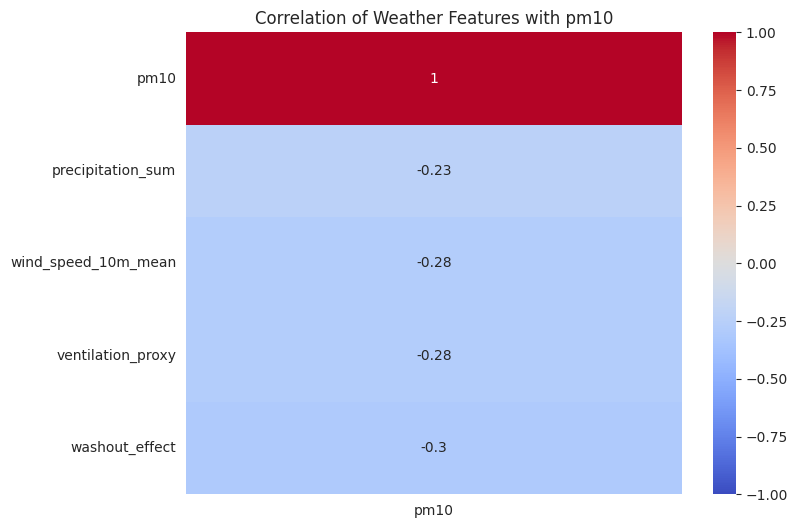

Saved merged data to dataset/merged_data_v1.csv


In [14]:
# Calculate correlation between PM10 and meteorological features
# Only if pm10 exists in dataset (usually lower case or upper case depending on cleaning)
# Let's check columns first
print("Columns:", merged_df.columns)

target_pollutant = 'pm10' # Adjust if pollutant column name is different
metric_cols = [target_pollutant, 'precipitation_sum', 'wind_speed_10m_mean', 'washout_effect', 'ventilation_proxy']

if target_pollutant in merged_df.columns:
    corr_matrix = merged_df[metric_cols].corr()
    print("\nCorrelation Matrix (PM10 vs Weather):")
    print(corr_matrix[[target_pollutant]])
    
    # Visualize
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix[[target_pollutant]].sort_values(by=target_pollutant, ascending=False), 
                annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f'Correlation of Weather Features with {target_pollutant}')
    plt.show()
else:
    print(f"Column '{target_pollutant}' not found for correlation analysis.")

# Save to CSV
output_path = 'dataset/merged_data_v1.csv'
# If writing to parent dataset folder, use '../dataset/'
merged_df.to_csv(output_path, index=False)
print(f"Saved merged data to {output_path}")